<a href="https://colab.research.google.com/github/Eylulumcagla/LaboratoryOfComputationalPhysics_Y8/blob/main/LCP_final_assignment_xgb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#all imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

####Metadata

In [ ]:
file='/content/drive/MyDrive/Magic_dataset/magic04.names'
with open(file, 'r') as f:
    lines = f.readlines()
    for line in lines:
        print(line)

1. Title of Database: MAGIC gamma telescope data 2004



2. Sources:



   (a) Original owner of the database:



       R. K. Bock

       Major Atmospheric Gamma Imaging Cherenkov Telescope project (MAGIC)

       http://wwwmagic.mppmu.mpg.de

       rkb@mail.cern.ch



   (b) Donor:



       P. Savicky

       Institute of Computer Science, AS of CR

       Czech Republic

       savicky@cs.cas.cz



   (c) Date received: May 2007



3. Past Usage:



   (a) Bock, R.K., Chilingarian, A., Gaug, M., Hakl, F., Hengstebeck, T.,

       Jirina, M., Klaschka, J., Kotrc, E., Savicky, P., Towers, S.,

       Vaicilius, A., Wittek W. (2004).

       Methods for multidimensional event classification: a case study

       using images from a Cherenkov gamma-ray telescope.

       Nucl.Instr.Meth. A, 516, pp. 511-528.



   (b) P. Savicky, E. Kotrc.

       Experimental Study of Leaf Confidences for Random Forest.

       Proceedings of COMPSTAT 2004, In: Computational Statistics.

       (Ed.

####Inspect Data

In [ ]:
file='/content/drive/MyDrive/Magic_dataset/magic04.data'
column= ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
data=pd.read_csv(file, names=column)
df=pd.DataFrame(data)
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000
mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026
std,42.364855,18.346056,0.472599,0.182813,0.110511,59.206062,51.000118,20.827439,26.103621,74.731787
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
25%,24.336000,11.863800,2.477100,0.235800,0.128475,-20.586550,-12.842775,-10.849375,5.547925,142.492250
50%,37.147700,17.139900,2.739600,0.354150,0.196500,4.013050,15.314100,0.666200,17.679500,191.851450
75%,70.122175,24.739475,3.101600,0.503700,0.285225,24.063700,35.837800,10.946425,45.883550,240.563825
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000


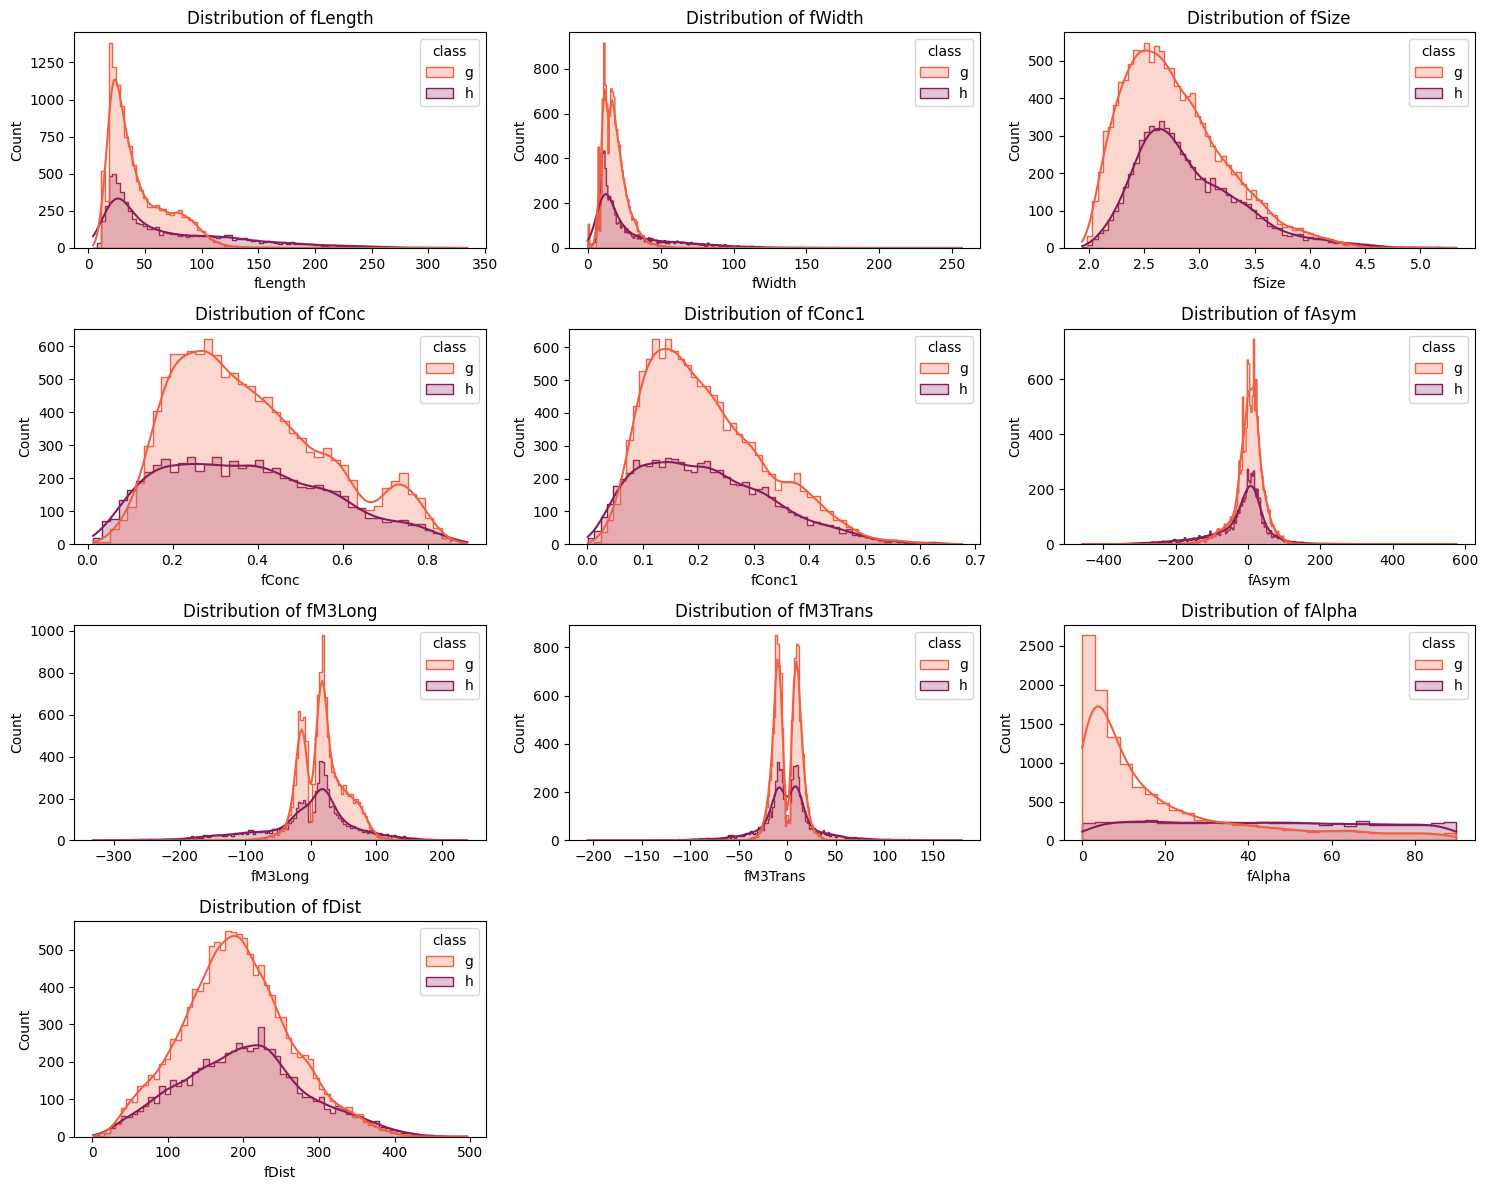

In [ ]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(column[:-1]):
    plt.subplot(4, 3, i+1)
    sns.histplot(data=df, x=col, hue="class", kde=True, element="step", palette="rocket_r")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [ ]:
print(df.isnull().sum(),'\n')
print((df==0).sum())

fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64 

fLength      0
fWidth      98
fSize        0
fConc        0
fConc1       0
fAsym       41
fM3Long     39
fM3Trans    59
fAlpha       5
fDist        0
class        0
dtype: int64


In [ ]:
Y=df['class_num'] = df['class'].map({'g': 1, 'h': 0})
X=df.drop(["class","class_num"],axis=1)

In [ ]:
print(X)

        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist  
0       -8.2027  40.0920   81.8828  
1       -9.9574   6.3609  205.2610  
2      -45.2

### Splitting Data into Training and Testing Sets

We will separate the features (X) from the target variable (y) and then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

# Calculate scale_pos_weight for class imbalance
neg_count = y_train.value_counts()[0]  # count of 'h'
pos_count = y_train.value_counts()[1]  # count of 'g'
# Formula: count(negative samples) / count(positive samples)
scale_pos_weight_val = neg_count / pos_count
print(f"\nCalculated scale_pos_weight: {scale_pos_weight_val:.2f}")

# Apply StandardScaler to features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Convert scaled arrays back to DataFrames, retaining column names
x_train = pd.DataFrame(x_train_scaled, columns=X.columns, index=x_train.index)
x_test = pd.DataFrame(x_test_scaled, columns=X.columns, index=x_test.index)


Calculated scale_pos_weight: 0.54


##Ex1
Model Selection & Regularization
Identify the simplest yet effective XGBoost model with good validation accuracy by:
- Running a search over hyperparameter space
- Analyzing which parameters matter most (structural vs. regularization

### Hyperparameter Tuning with GridSearchCV for XGBoost

In [ ]:
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                          use_label_encoder=False, random_state=42,
                          scale_pos_weight=scale_pos_weight_val) # Added scale_pos_weight

# Define the hyperparameter space to search
# Focusing on structural parameters (max_depth, n_estimators) and regularization (lambda, alpha)
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.9],        # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2],         # Minimum loss reduction required to make a further partition on a leaf node of the tree
    'reg_alpha': [0, 0.1, 0.5],     # L1 regularization term on weights
    'reg_lambda': [1, 1.5, 2]       # L2 regularization term on weights
}

# Set up GridSearchCV
# Using a smaller cv value for quicker execution, consider increasing for production
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(x_train, y_train) # x_train is now scaled from the previous cell

print(f"Best hyperparameters found: {grid_search.best_params_}")
print(f"Best accuracy found: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 2916 candidates, totalling 8748 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:25:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best hyperparameters found: {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.9}
Best accuracy found: 0.8756


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.9 MB/s eta 0:00:00


In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import accuracy_score

def objective(trial):
    # These are the "knobs" Optuna will turn to find the 90%+ mark
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
    }

    # Initialize and train with the current guess
    model = xgb.XGBClassifier(**param, random_state=42, eval_metric='logloss')
    model.fit(x_train, y_train)

    # Check accuracy
    preds = model.predict(x_test)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

# 2. Run the "Study"
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # It will try 50 different "recipes"

print(f"Best Accuracy: {study.best_value * 100:.2f}%")
print("Best Params:", study.best_params)

[I 2026-05-06 05:27:35,734] A new study created in memory with name: no-name-5281c0a1-2678-44d7-9cab-784c0146a16d
[I 2026-05-06 05:28:06,159] Trial 0 finished with value: 0.8836312653347353 and parameters: {'n_estimators': 622, 'max_depth': 7, 'learning_rate': 0.126841766451922, 'subsample': 0.7763700867816985, 'colsample_bytree': 0.8228121058992126, 'gamma': 0.009132912264782573}. Best is trial 0 with value: 0.8836312653347353.
[I 2026-05-06 05:28:09,473] Trial 1 finished with value: 0.8866105853487557 and parameters: {'n_estimators': 143, 'max_depth': 10, 'learning_rate': 0.05739344972218395, 'subsample': 0.6344763746003246, 'colsample_bytree': 0.7586336595767088, 'gamma': 1.6510137546024636e-08}. Best is trial 1 with value: 0.8866105853487557.
[I 2026-05-06 05:28:10,858] Trial 2 finished with value: 0.8801261829652997 and parameters: {'n_estimators': 645, 'max_depth': 5, 'learning_rate': 0.25816800197157097, 'subsample': 0.6561770581497887, 'colsample_bytree': 0.6054011370243075, 'g

Best Accuracy: 89.06%
Best Params: {'n_estimators': 904, 'max_depth': 7, 'learning_rate': 0.023238110840491263, 'subsample': 0.621614034372936, 'colsample_bytree': 0.9507359536099996, 'gamma': 1.3571017308799172e-05}


In [ ]:
best_xgb_params = {
    'n_estimators': 904,
    'max_depth': 7,
    'learning_rate': 0.023238110840491263,
    'subsample': 0.621614034372936,
    'colsample_bytree': 0.9507359536099996,
    'gamma': 1.3571017308799172e-05,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False, # Retain this if you want to suppress the warning
    'random_state': 42,
    'scale_pos_weight': scale_pos_weight_val # Ensure scale_pos_weight is included if previously used
}

best_xgb_model = XGBClassifier(**best_xgb_params)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:30:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Accuracy: 0.8884

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      2006
           1       0.91      0.92      0.91      3700

    accuracy                           0.89      5706
   macro avg       0.88      0.87      0.88      5706
weighted avg       0.89      0.89      0.89      5706


Confusion Matrix:


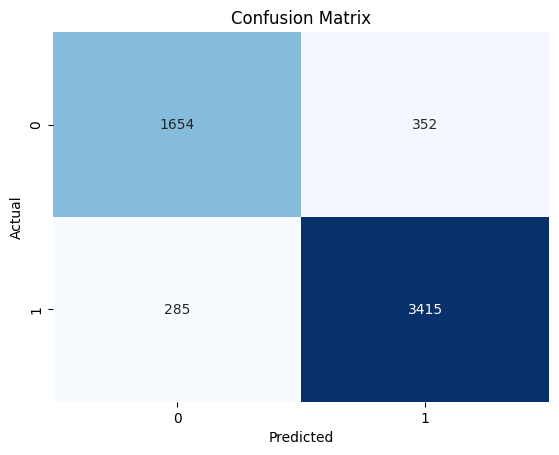

In [ ]:
best_xgb_model.fit(x_train, y_train) # Fit the model to the training data
y_pred = best_xgb_model.predict(x_test)
y_pred_proba = best_xgb_model.predict_proba(x_test)[:, 1]
#accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
#classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
#confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Analyzing Feature Importance

Understanding feature importance helps in identifying which structural parameters (features) contribute most to the model's predictions. This can guide further feature engineering or selection.

In [ ]:
# To get all three and compare:
for importance_type in ['weight', 'gain', 'cover']:
    print(f"Importance by {importance_type}:")
    print(best_xgb_model.get_booster().get_score(importance_type=importance_type))

Importance by weight:
{'fLength': 5789.0, 'fWidth': 5855.0, 'fSize': 6132.0, 'fConc': 4107.0, 'fConc1': 4044.0, 'fAsym': 4747.0, 'fM3Long': 5240.0, 'fM3Trans': 4635.0, 'fAlpha': 5897.0, 'fDist': 5594.0}
Importance by gain:
{'fLength': 5.732993125915527, 'fWidth': 3.3994765281677246, 'fSize': 3.4399638175964355, 'fConc': 2.6039977073669434, 'fConc1': 2.4965157508850098, 'fAsym': 1.787753701210022, 'fM3Long': 2.4757838249206543, 'fM3Trans': 1.720580816268921, 'fAlpha': 7.8484625816345215, 'fDist': 2.4392740726470947}
Importance by cover:
{'fLength': 79.96131134033203, 'fWidth': 79.85186004638672, 'fSize': 74.23051452636719, 'fConc': 69.17132568359375, 'fConc1': 68.23088836669922, 'fAsym': 56.93855285644531, 'fM3Long': 69.16332244873047, 'fM3Trans': 55.04335403442383, 'fAlpha': 91.61393737792969, 'fDist': 65.56403350830078}


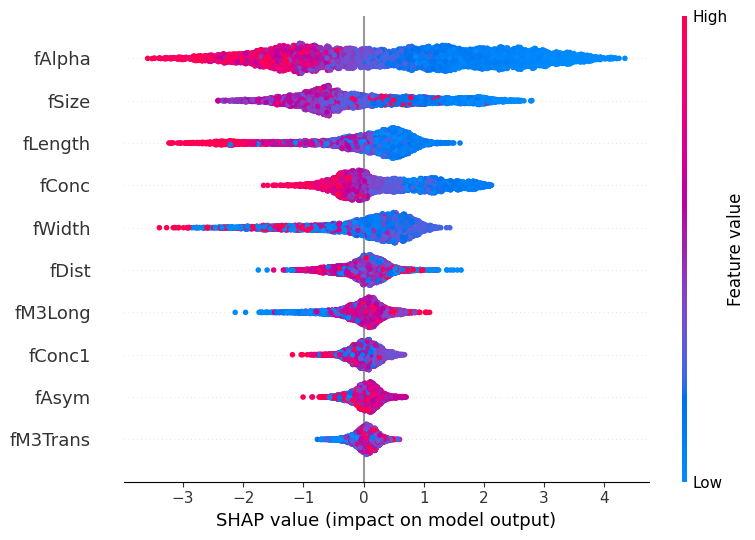

In [ ]:
import shap
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)

In [ ]:
# List of features to drop based on the analysis
features_to_drop = ['fM3Trans', 'fAsym']

x_train_reduced = x_train.drop(columns=features_to_drop)
x_test_reduced = x_test.drop(columns=features_to_drop)

reduced_model = XGBClassifier(**best_xgb_params)
reduced_model.fit(x_train_reduced, y_train)
y_pred_reduced = reduced_model.predict(x_test_reduced)
new_accuracy = accuracy_score(y_test, y_pred_reduced)

print(f"Original Accuracy: 0.8884")
print(f"Reduced Accuracy: {new_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:32:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Original Accuracy: 0.8884
Reduced Accuracy: 0.8863


In [ ]:
# List of features to drop based on the analysis
features_to_drop = ['fM3Trans', 'fAsym', 'fConc1']

x_train_reduced = x_train.drop(columns=features_to_drop)
x_test_reduced = x_test.drop(columns=features_to_drop)

reduced_model = XGBClassifier(**best_xgb_params)
reduced_model.fit(x_train_reduced, y_train)
y_pred_reduced = reduced_model.predict(x_test_reduced)
new_accuracy = accuracy_score(y_test, y_pred_reduced)

print(f"Original Accuracy: 0.8884")
print(f"Reduced Accuracy: {new_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:33:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Original Accuracy: 0.8884
Reduced Accuracy: 0.8843


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:43:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:43:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:43:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:43:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

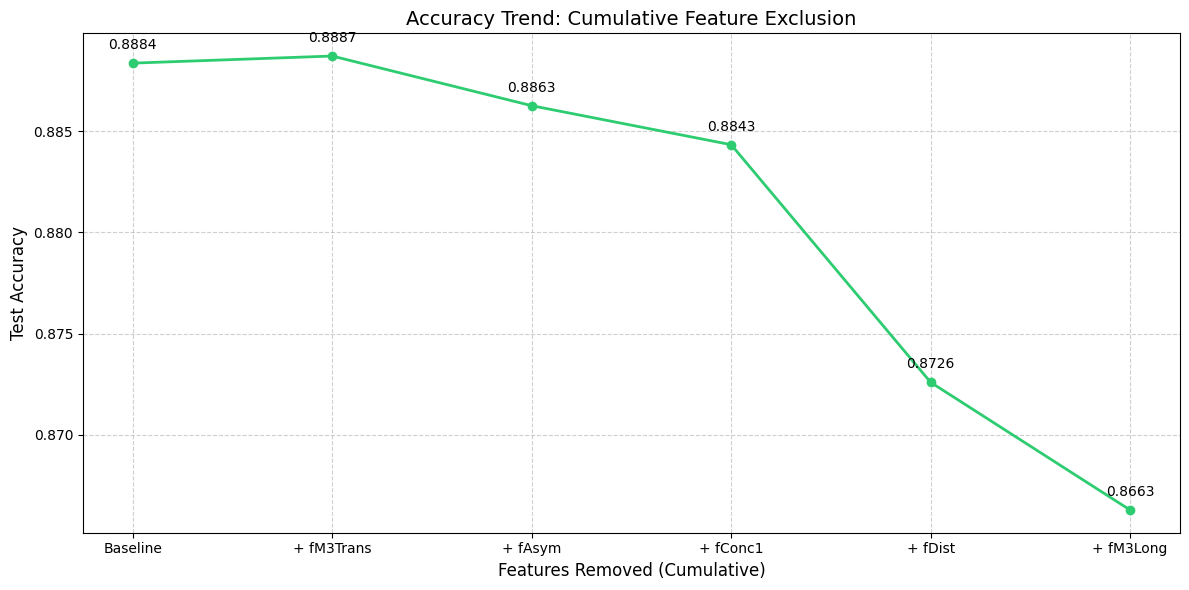

  dropped_names  accuracy
0      Baseline  0.888363
1    + fM3Trans  0.888714
2       + fAsym  0.886260
3      + fConc1  0.884332
4       + fDist  0.872590
5     + fM3Long  0.866281


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier # Swap for XGBClassifier locally
from sklearn.metrics import accuracy_score

# 1. Define the cumulative drop list
features_to_drop = ['fM3Trans', 'fAsym', 'fConc1', 'fDist', 'fM3Long']
results = []

# --- Step 1: Baseline Accuracy (All Features) ---
model = XGBClassifier(**best_xgb_params)
model.fit(x_train, y_train)
baseline_acc = accuracy_score(y_test, model.predict(x_test))
results.append({'num_dropped': 0, 'dropped_names': 'Baseline', 'accuracy': baseline_acc})

# --- Step 2: Iterative Removal Loop ---
current_dropped = []
for feat in features_to_drop:
    current_dropped.append(feat)

    # Drop cumulative features
    x_train_sub = x_train.drop(columns=current_dropped)
    x_test_sub = x_test.drop(columns=current_dropped)

    # Re-train
    model = XGBClassifier(**best_xgb_params)
    model.fit(x_train_sub, y_train)

    # Evaluate
    acc = accuracy_score(y_test, model.predict(x_test_sub))
    results.append({
        'num_dropped': len(current_dropped),
        'dropped_names': f"+ {feat}", # Label for X-axis
        'accuracy': acc
    })

# --- Step 3: Visualization ---
res_df = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
plt.plot(res_df['num_dropped'], res_df['accuracy'], marker='o', linewidth=2, color='#2ecc71')

# Formatting the plot
plt.title('Accuracy Trend: Cumulative Feature Exclusion', fontsize=14)
plt.xlabel('Features Removed (Cumulative)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xticks(res_df['num_dropped'], res_df['dropped_names'])
plt.grid(True, linestyle='--', alpha=0.6)

# Adding text labels for accuracy values
for i, txt in enumerate(res_df['accuracy']):
    plt.annotate(f"{txt:.4f}", (res_df['num_dropped'][i], res_df['accuracy'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

# Display numeric table
print(res_df[['dropped_names', 'accuracy']])

## Feedforward Neural Network (FFNN) Model

In [ ]:
pip install scikeras[tensorflow]

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier

# Function to create the FFNN model for KerasClassifier
def create_ffnn_model(optimizer='adam', learning_rate=0.001, activation='relu', dropout_rate=0.2, neurons=64, num_layers=1):
    model = Sequential()

    # Input layer and first hidden layer
    model.add(Dense(neurons, input_dim=x_train.shape[1], activation=activation))
    model.add(Dropout(dropout_rate))

    # Additional hidden layers
    for _ in range(num_layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(dropout_rate))

    # Output layer (binary classification, so 1 neuron with sigmoid activation)
    model.add(Dense(1, activation='sigmoid'))

    # Configure optimizer based on choice
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    else: # Default to Adam if other optimizers are not explicitly handled
        opt = Adam(learning_rate=learning_rate)

    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

print("FFNN model creation function defined.")

FFNN model creation function defined.


### Hyperparameter Tuning for FFNN with GridSearchCV

We will use `KerasClassifier` to wrap our Keras model and then apply `GridSearchCV` to explore a range of hyperparameters such as `neurons`, `num_layers`, `activation` functions, `dropout_rate`, `learning_rate`, `batch_size`, and `epochs`.

In [ ]:
# Create a KerasClassifier wrapper for the FFNN model
ffnn_model = KerasClassifier(model=create_ffnn_model, verbose=0, random_state=42)

# Define the hyperparameter space to search for FFNN
param_grid_ffnn = {
    'model__neurons': [32, 64, 128],
    'model__num_layers': [1, 2],
    'model__activation': ['relu', 'tanh'],
    'model__dropout_rate': [0.2, 0.4],
    'model__learning_rate': [0.001, 0.01],
    'batch_size': [32, 64],
    'epochs': [50, 100] # Reduced epochs for faster execution, consider increasing for better results
}

# Set up GridSearchCV for FFNN
grid_search_ffnn = GridSearchCV(estimator=ffnn_model, param_grid=param_grid_ffnn, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the scaled training data
print("\nStarting GridSearchCV for FFNN... This might take a while.")
grid_search_ffnn.fit(x_train, y_train)

print(f"\nBest hyperparameters for FFNN found: {grid_search_ffnn.best_params_}")
print(f"Best accuracy for FFNN found: {grid_search_ffnn.best_score_:.4f}")


Starting GridSearchCV for FFNN... This might take a while.
Fitting 3 folds for each of 192 candidates, totalling 576 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best hyperparameters for FFNN found: {'batch_size': 64, 'epochs': 100, 'model__activation': 'relu', 'model__dropout_rate': 0.2, 'model__learning_rate': 0.01, 'model__neurons': 128, 'model__num_layers': 1}
Best accuracy for FFNN found: 0.8751


### FFNN Model Evaluation with Best Parameters

Let's evaluate the performance of the best FFNN model found by `GridSearchCV` on the test set. We'll look at accuracy, classification report, and a confusion matrix.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy of Best FFNN Model: 0.8474

Classification Report for Best FFNN Model:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80      2006
           1       0.92      0.84      0.88      3700

    accuracy                           0.85      5706
   macro avg       0.83      0.85      0.84      5706
weighted avg       0.86      0.85      0.85      5706


Confusion Matrix for Best FFNN Model:


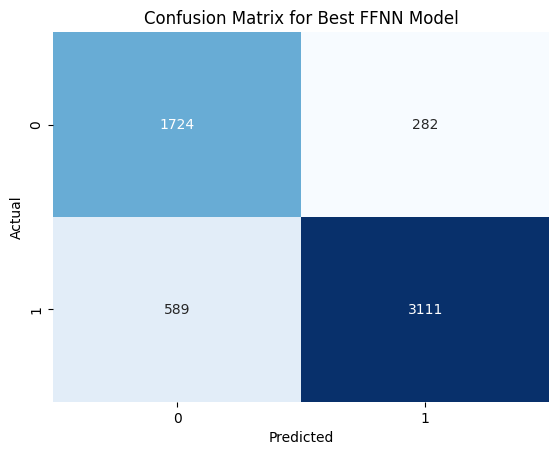

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights for the FFNN model based on the full training data
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
# Convert to dictionary format required by Keras fit method
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}

# Get the best FFNN model from GridSearchCV
# best_ffnn_model = grid_search_ffnn.best_estimator_

# Manually define the best FFNN model using the optimal hyperparameters found
best_ffnn_model = KerasClassifier(
    model=create_ffnn_model,
    model__neurons=128,
    model__num_layers=1,
    model__activation='relu',
    model__dropout_rate=0.2,
    model__learning_rate=0.01,
    batch_size=64,
    epochs=100,
    verbose=0,
    random_state=42
)

# Fit the model to the training data, passing class_weight_dict
best_ffnn_model.fit(x_train, y_train, class_weight=class_weight_dict);

# Make predictions on the test set
y_pred_ffnn = best_ffnn_model.predict(x_test)
y_pred_proba_ffnn = best_ffnn_model.predict_proba(x_test)[:, 1]

# Evaluate the FFNN model
accuracy_ffnn = accuracy_score(y_test, y_pred_ffnn)
print(f"Test Accuracy of Best FFNN Model: {accuracy_ffnn:.4f}")

print("\nClassification Report for Best FFNN Model:")
print(classification_report(y_test, y_pred_ffnn))

print("\nConfusion Matrix for Best FFNN Model:")
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Best FFNN Model')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight # Import class_weight

# Use the already defined x_train and y_train as the full training set for learning curve experiments
x_full_for_lc, y_full_for_lc = x_train, y_train

fractions = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results=[]

for frac in fractions:
  # Calculate the number of samples for the current fraction based on the full training data size
  n_samples=max(50,int(frac*len(x_full_for_lc)))

  # Select a subset of the full training data using .iloc to maintain correct indexing
  x_tr = x_full_for_lc.iloc[:n_samples]
  y_tr = y_full_for_lc.iloc[:n_samples]

  xgb_cv, ffnn_cv=[],[]

  for fold_idx, (train_idx,val_idx) in enumerate(skf.split(x_tr,y_tr)):
    # Use .iloc for positional indexing when splitting folds
    x_fold_tr, x_fold_val = x_tr.iloc[train_idx], x_tr.iloc[val_idx]
    y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

    # Calculate class weights for the current fold's training data
    # Ensure y_fold_tr is a numpy array for compute_class_weight
    fold_class_weights_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_fold_tr),
        y=y_fold_tr
    )
    fold_class_weight_dict = {0: fold_class_weights_array[0], 1: fold_class_weights_array[1]}


    #xgb
    xgb_model=best_xgb_model
    # XGBoost already has scale_pos_weight configured from best_xgb_params
    xgb_model.fit(x_fold_tr,y_fold_tr)
    xgb_cv.append(accuracy_score(y_fold_val,xgb_model.predict(x_fold_val)))

    #ffnn
    ffnn_model=best_ffnn_model
    # Fit FFNN model with class weights
    ffnn_model.fit(x_fold_tr,y_fold_tr, class_weight=fold_class_weight_dict) # Pass class_weight here
    ffnn_cv.append(accuracy_score(y_fold_val,ffnn_model.predict(x_fold_val)))

  results.append({
      'frac': frac,
      'n':  n_samples,
      'xgb_mean': np.mean(xgb_cv),
      'xgb_std': np.std(xgb_cv),
      'ffnn_mean': np.mean(ffnn_cv),
      'ffnn_std':  np.std(ffnn_cv)
  })
  print(f"frac={frac:.2f}  N'={n_samples:5d} | "
          f"XGB  {np.mean(xgb_cv):.4f} ± {np.std(xgb_cv):.4f} | "
          f"FFNN {np.mean(ffnn_cv):.4f} ± {np.std(ffnn_cv):.4f}")

# result
print(f"\n{'Frac':>6} {'N':>7} | {'XGB mean':>10} {'±std':>7} | {'FFNN mean':>10} {'±std':>7} | Winner")
print("-" * 72)
for r in results:
    winner = "XGB" if r['xgb_mean'] > r['ffnn_mean'] else "FFNN"
    print(f"{r['frac']:6.2f} {r['n']:7d} | "
          f"{r['xgb_mean']:10.4f} {r['xgb_std']:7.4f} | "
          f"{r['ffnn_mean']:10.4f} {r['ffnn_std']:7.4f} | {winner}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:50:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:50:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `

frac=0.05  N'=  665 | XGB  0.8436 ± 0.0174 | FFNN 0.8150 ± 0.0276


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:51:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:51:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `

frac=0.10  N'= 1331 | XGB  0.8460 ± 0.0168 | FFNN 0.8370 ± 0.0200


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:52:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:52:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `

...

frac=0.80  N'=10651 | XGB  0.8745 ± 0.0052 | FFNN 0.8648 ± 0.0099


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:10:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:10:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `

frac=0.90  N'=11982 | XGB  0.8731 ± 0.0068 | FFNN 0.8589 ± 0.0090


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:14:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:14:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `

frac=1.00  N'=13314 | XGB  0.8754 ± 0.0077 | FFNN 0.8681 ± 0.0098

  Frac       N |   XGB mean    ±std |  FFNN mean    ±std | Winner
------------------------------------------------------------------------
  0.05     665 |     0.8436  0.0174 |     0.8150  0.0276 | XGB
  0.10    1331 |     0.8460  0.0168 |     0.8370  0.0200 | XGB
  0.20    2662 |     0.8603  0.0129 |     0.8512  0.0155 | XGB
  0.30    3994 |     0.8630  0.0070 |     0.8520  0.0060 | XGB
  0.40    5325 |     0.8610  0.0105 |     0.8605  0.0180 | XGB
  0.50    6657 |     0.8707  0.0071 |     0.8624  0.0096 | XGB
  0.60    7988 |     0.8721  0.0060 |     0.8658  0.0071 | XGB
  0.70    9319 |     0.8729  0.0071 |     0.8633  0.0124 | XGB
  0.80   10651 |     0.8745  0.0052 |     0.8648  0.0099 | XGB
  0.90   11982 |     0.8731  0.0068 |     0.8589  0.0090 | XGB
  1.00   13314 |     0.8754  0.0077 |     0.8681  0.0098 | XGB


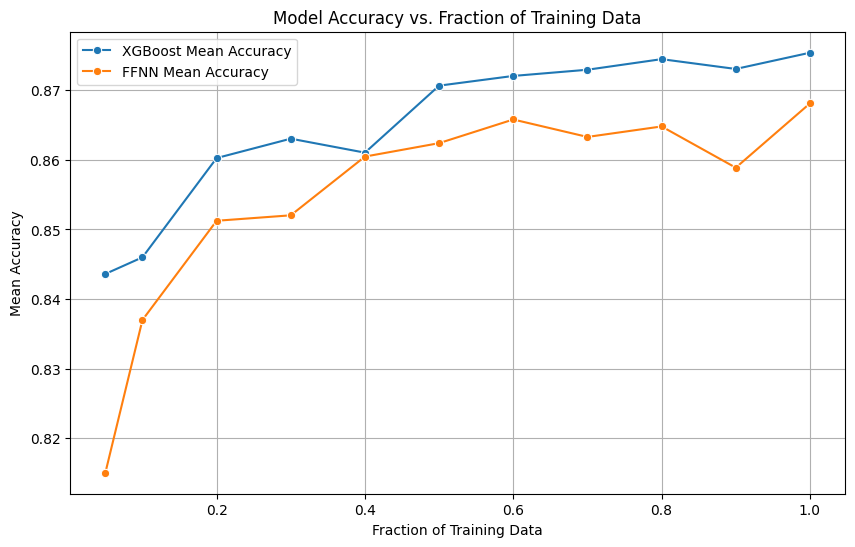

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to a DataFrame for easier plotting
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.lineplot(x='frac', y='xgb_mean', data=results_df, marker='o', label='XGBoost Mean Accuracy')
sns.lineplot(x='frac', y='ffnn_mean', data=results_df, marker='o', label='FFNN Mean Accuracy')

plt.title('Model Accuracy vs. Fraction of Training Data')
plt.xlabel('Fraction of Training Data')
plt.ylabel('Mean Accuracy')
plt.grid(True)
plt.legend()
plt.show()

##Extention
The paper [Comparative performance analysis of quantum feature maps for quantum kernel-based machine learning](https://www.nature.com/articles/s41598-026-39392-9) highlights using Quantum feature maps like ZZFeature Map to project classical data into high-dimensional Hilbert space. Especially in our dataset we can visualize in 3d pca projection that the gamma and hadron over-lapping are non-linear, hence we expect this kind of feature maps will improve the results.

In [ ]:
!pip install qiskit
!pip install qiskit_machine_learning

In [ ]:
!pip install pylatexenc

/tmp/ipykernel_78161/4026223520.py:6: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')


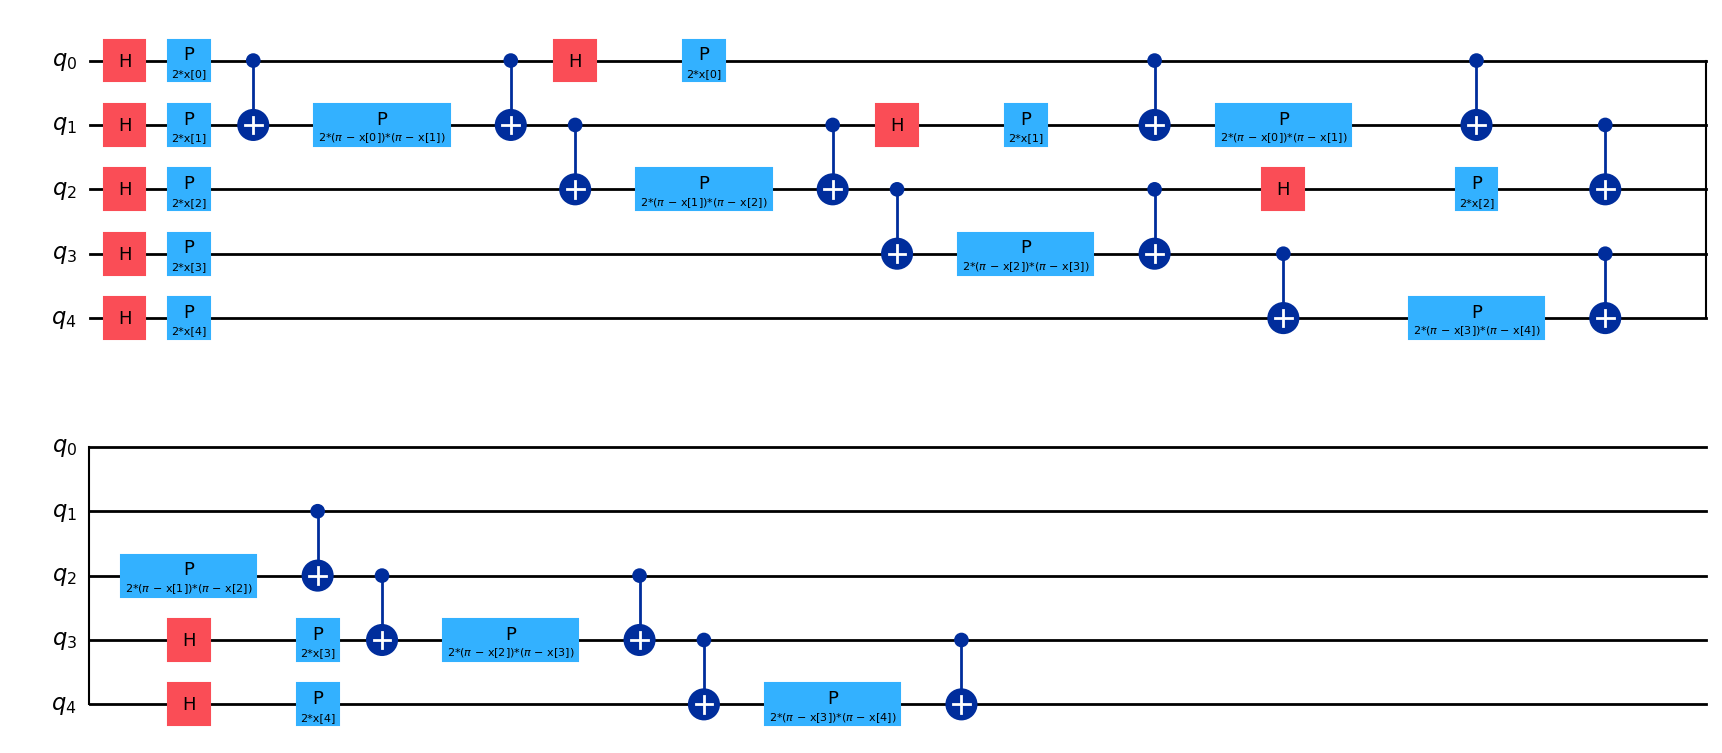

In [ ]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# We use 5 qubits for the top 5 features
num_qubits = 5
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')

# Visualize the circuit
feature_map.decompose().draw(output='mpl')

Computing Kernal Matrix

Due to computational expense we are reducing features to top 5features and took only 500 points. Let's test this and if its significant result we can run it for a day with whole datapoints. Since for quantum feature map the range is from [0,pi] we use minmax scalar

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)
x_train_sample=x_train[:500]
x_test_sample=x_test[:500]
top_5_features = ['fAlpha', 'fLength', 'fSize', 'fWidth', 'fConc']
x_train_q = x_train_sample[top_5_features]
x_test_q = x_test_sample[top_5_features]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, np.pi))
x_train_scaled = scaler.fit_transform(x_train_q)
x_test_scaled = scaler.transform(x_test_q)

In [ ]:
kernel = FidelityQuantumKernel(feature_map=feature_map)

matrix_train = kernel.evaluate(x_vec=x_train_sample)
matrix_test = kernel.evaluate(x_vec=x_test_scaled, y_vec=x_train_sample)

KeyboardInterrupt: 

Comparison

In [ ]:
# Train XGB on the Quantum Matrix
q_xgb = XGBClassifier(**best_xgb_params)
q_xgb.fit(matrix_train, y_train)

q_preds = q_xgb.predict(matrix_test)
print(f"Quantum XGB Accuracy: {accuracy_score(y_test, q_preds)}")